In [1]:
from pathlib import Path

root = Path("data/cityscapes")

print("leftImg8bit exists:", (root / "leftImg8bit").exists())
print("gtFine exists:", (root / "gtFine").exists())

for split in ["train", "val", "test"]:
    print(split, "images:", (root / "leftImg8bit" / split).exists())
    print(split, "labels:", (root / "gtFine" / split).exists())

leftImg8bit exists: True
gtFine exists: True
train images: True
train labels: True
val images: True
val labels: True
test images: True
test labels: True


In [2]:
from pathlib import Path

img_files = list((Path("data/cityscapes/leftImg8bit/train")).rglob("*_leftImg8bit.png"))
label_files = list((Path("data/cityscapes/gtFine/train")).rglob("*_gtFine_labelIds.png"))

print("Number of train images:", len(img_files))
print("Number of train labels:", len(label_files))

print("Example image:", img_files[0] if img_files else "None")
print("Example label:", label_files[0] if label_files else "None")

Number of train images: 2975
Number of train labels: 2975
Example image: data\cityscapes\leftImg8bit\train\aachen\aachen_000000_000019_leftImg8bit.png
Example label: data\cityscapes\gtFine\train\aachen\aachen_000000_000019_gtFine_labelIds.png


In [1]:
from pathlib import Path

root = Path("data/cityscapes")

for split in ["train", "val", "test"]:
    img_dir = root / "leftImg8bit" / split
    gt_dir = root / "gtFine" / split

    images = list(img_dir.rglob("*_leftImg8bit.png"))
    labels = list(gt_dir.rglob("*_gtFine_labelIds.png"))

    print(f"{split.upper()}:")
    print(f"  Images : {len(images)}")
    print(f"  Labels : {len(labels)}")
    print("-" * 40)

TRAIN:
  Images : 2975
  Labels : 2975
----------------------------------------
VAL:
  Images : 500
  Labels : 500
----------------------------------------
TEST:
  Images : 1525
  Labels : 1525
----------------------------------------


In [2]:
from pathlib import Path

root = Path("data/cityscapes")

for split in ["train", "val", "test"]:
    city_dirs = sorted([p.name for p in (root / "leftImg8bit" / split).iterdir() if p.is_dir()])
    print(f"{split.upper()} - nombre de villes: {len(city_dirs)}")
    print(city_dirs[:10], "..." if len(city_dirs) > 10 else "")
    print("-" * 60)

TRAIN - nombre de villes: 18
['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt', 'dusseldorf', 'erfurt', 'hamburg', 'hanover', 'jena'] ...
------------------------------------------------------------
VAL - nombre de villes: 3
['frankfurt', 'lindau', 'munster'] 
------------------------------------------------------------
TEST - nombre de villes: 6
['berlin', 'bielefeld', 'bonn', 'leverkusen', 'mainz', 'munich'] 
------------------------------------------------------------


Image path: data\cityscapes\leftImg8bit\train\aachen\aachen_000000_000019_leftImg8bit.png
Mask path : data\cityscapes\gtFine\train\aachen\aachen_000000_000019_gtFine_labelIds.png
Image shape: (1024, 2048, 3)
Mask shape : (1024, 2048)
Unique raw labels: [ 0  1  3  4  7  8 11 17 20 21 22 23 24 25 26 33]


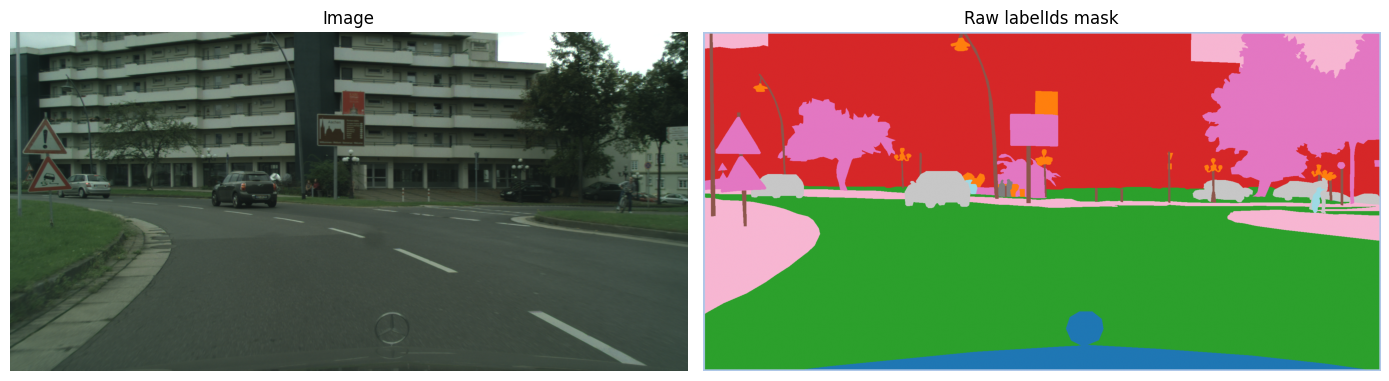

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

root = Path("data/cityscapes")

img_path = next((root / "leftImg8bit" / "train").rglob("*_leftImg8bit.png"))

relative = img_path.relative_to(root / "leftImg8bit" / "train")
mask_name = img_path.name.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
mask_path = root / "gtFine" / "train" / relative.parent / mask_name

image = np.array(Image.open(img_path).convert("RGB"))
mask = np.array(Image.open(mask_path))

print("Image path:", img_path)
print("Mask path :", mask_path)
print("Image shape:", image.shape)
print("Mask shape :", mask.shape)
print("Unique raw labels:", np.unique(mask)[:50])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab20")
plt.title("Raw labelIds mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
from PIL import Image
import numpy as np

root = Path("data/cityscapes")
img_files = list((root / "leftImg8bit" / "train").rglob("*_leftImg8bit.png"))

sizes = []
for p in img_files[:200]:  # échantillon pour aller plus vite
    with Image.open(p) as im:
        sizes.append(im.size)  # (width, height)

sizes = np.array(sizes)
print("Largeurs uniques (sample):", np.unique(sizes[:, 0]))
print("Hauteurs uniques (sample):", np.unique(sizes[:, 1]))
print("Taille moyenne (w,h):", sizes.mean(axis=0))

Largeurs uniques (sample): [2048]
Hauteurs uniques (sample): [1024]
Taille moyenne (w,h): [2048. 1024.]


In [7]:
import numpy as np
from PIL import Image
from pathlib import Path

CITYSCAPES_ID_TO_TRAIN_ID = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255,
}

def encode_cityscapes_mask(mask):
    encoded = np.full(mask.shape, 255, dtype=np.uint8)
    for k, v in CITYSCAPES_ID_TO_TRAIN_ID.items():
        encoded[mask == k] = v
    return encoded

root = Path("data/cityscapes")
mask_path = next((root / "gtFine" / "train").rglob("*_gtFine_labelIds.png"))

raw_mask = np.array(Image.open(mask_path), dtype=np.int64)
train_mask = encode_cityscapes_mask(raw_mask)

print("Unique raw labels   :", np.unique(raw_mask))
print("Unique mapped labels:", np.unique(train_mask))

Unique raw labels   : [ 0  1  3  4  7  8 11 17 20 21 22 23 24 25 26 33]
Unique mapped labels: [  0   1   2   5   7   8   9  10  11  12  13  18 255]


In [8]:
from pathlib import Path
from PIL import Image
import numpy as np
from collections import Counter

CITYSCAPES_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic_light", "traffic_sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train",
    "motorcycle", "bicycle"
]

root = Path("data/cityscapes")
mask_files = list((root / "gtFine" / "train").rglob("*_gtFine_labelIds.png"))

counter = Counter()

for p in mask_files[:200]:  # sample
    raw_mask = np.array(Image.open(p), dtype=np.int64)
    mapped = encode_cityscapes_mask(raw_mask)
    vals, counts = np.unique(mapped, return_counts=True)
    for v, c in zip(vals, counts):
        if v != 255:
            counter[int(v)] += int(c)

print("Distribution approximative des classes (sample):")
for class_id, class_name in enumerate(CITYSCAPES_CLASSES):
    print(f"{class_id:2d} - {class_name:15s}: {counter[class_id]}")

Distribution approximative des classes (sample):
 0 - road           : 139937886
 1 - sidewalk       : 21961631
 2 - building       : 94756427
 3 - wall           : 1739038
 4 - fence          : 1371092
 5 - pole           : 4218387
 6 - traffic_light  : 834897
 7 - traffic_sign   : 2277125
 8 - vegetation     : 63349064
 9 - terrain        : 5098357
10 - sky            : 11210034
11 - person         : 3730147
12 - rider          : 203960
13 - car            : 26332995
14 - truck          : 445411
15 - bus            : 836675
16 - train          : 18131
17 - motorcycle     : 445920
18 - bicycle        : 1040342


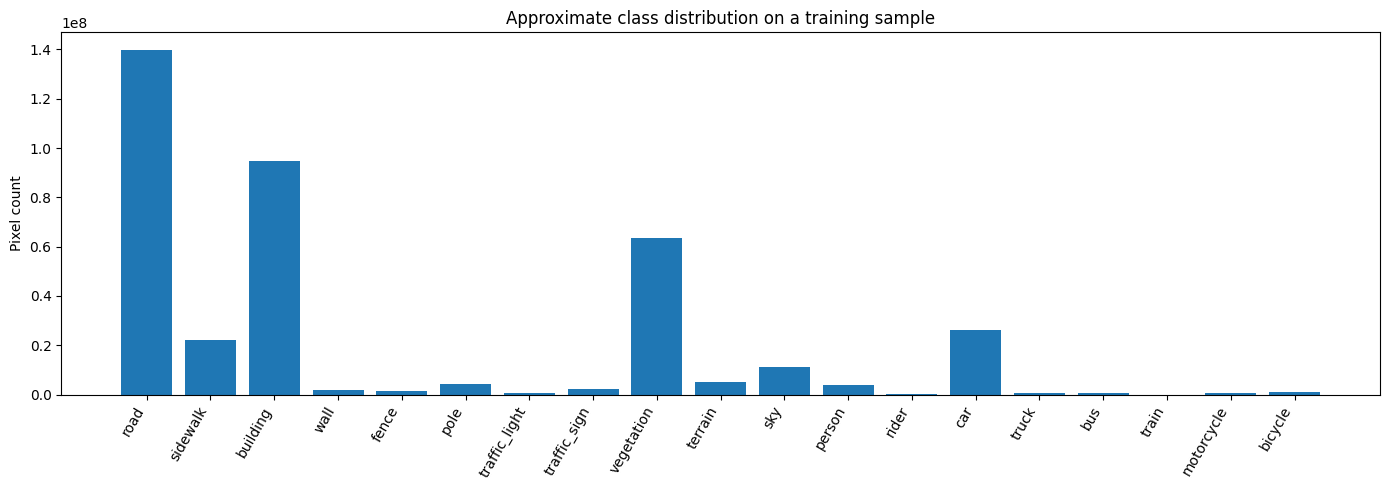

In [9]:
import matplotlib.pyplot as plt

class_counts = [counter[i] for i in range(len(CITYSCAPES_CLASSES))]

plt.figure(figsize=(14, 5))
plt.bar(CITYSCAPES_CLASSES, class_counts)
plt.xticks(rotation=60, ha="right")
plt.title("Approximate class distribution on a training sample")
plt.ylabel("Pixel count")
plt.tight_layout()
plt.show()